# Logistic Regression Model

In [ ]:
!pip install pandas matplotlib scipy scikit-learn

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.feature_selection import f_classif, SelectKBest

In [27]:
### Data Preparation ###
expeditions = "data/expeditions.csv"
df_raw = pd.read_csv(expeditions)

# Filtering
df = df_raw[df_raw['max_elev_reached'] > 7000].copy()

# Binarize Target Variable
df['success'] = (df['mbrs_summited'] > 0).astype(int)

# Feature Selection & Engineering
# We will DROP 'leaders' and 'members' for now, as they are too complex to encode directly
# We will also DROP 'peak_name' and 'rte_1_name' for now due to high cardinality (high number of unique values)
numerical_features = [
    'year',
    'total_days',
    'max_elev_reached',
    'total_mbrs'
]

# These are features that are already binary (0/1) or can be treated as such.
binary_features = [
    'is_commercial_rte',
    'is_standard_rte',
    'is_o2_climbing'
]

# This is a good candidate for One-Hot Encoding as it has few categories.
categorical_features_low_cardinality = [
    'season'
]

# Combine into the final feature set for now
selected_features = numerical_features + binary_features + categorical_features_low_cardinality
all_cols_to_keep = selected_features + ['success']

# Subset and drop rows with NaN
df_model = df[all_cols_to_keep].dropna()

# One-Hot Encode the Low-Cardinality Categorical Features
# It creates new 0/1 columns for each category (e.g., 'season_Spring', 'season_Autumn').
df_model = pd.get_dummies(df_model, columns=categorical_features_low_cardinality, drop_first=True)

# Separate Features (X) and Target (y)
# 'success' is our target variable
X = df_model.drop('success', axis=1)
y = df_model['success']

# Rank the features
# Calculate F-scores and p-values for these numerical features
# f_classif returns two arrays: F-scores and p-values
f_scores, p_values = f_classif(X, y)

# Create a DataFrame to view the results, then sort by F-score
feature_ranking = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_scores,
    'P-Value': p_values
})

# Sort features by F-score in descending order to see the most important ones first
ranked_features = feature_ranking.sort_values(by='F-Score', ascending=False)

print("ANOVA F-test Feature Ranking")
print(ranked_features)

# Split data into training and testing sets
# This prevents information from the test set "leaking" into the training process.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the StandardScaler to normalize the features
scaler = StandardScaler()

# Fit the scaler on the data
# The scaler "learns" the mean and standard deviation from the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same fitted scaler
# It's crucial to only use .transform() here to apply the same scaling rules
X_test_scaled = scaler.transform(X_test)

# Initilize the Logistic Regression Model
# max_iter=1000 allows more training cycles if convergence takes time.
model = LogisticRegression(max_iter=1000)

# Fit the model to the training data
model.fit(X_train_scaled, y_train)

# With the model, predict the test data
y_pred = model.predict(X_test_scaled)

ANOVA F-test Feature Ranking
             Feature      F-Score        P-Value
2   max_elev_reached  1006.094194  4.004228e-204
6     is_o2_climbing   479.879410  2.324551e-102
0               year   100.164034   2.147227e-23
3         total_mbrs    81.138435   2.787796e-19
1         total_days    50.343014   1.441274e-12
9      season_Winter    29.934518   4.651459e-08
4  is_commercial_rte    16.968353   3.852416e-05
8      season_Summer    14.340183   1.540780e-04
7      season_Spring    11.002443   9.153829e-04
5    is_standard_rte     0.584361   4.446383e-01


Peirce Skill Score (PSS): 0.47
Heidke Skill Score (HSS): 0.52
--- Classification Report ---
              precision    recall  f1-score   support

 Failure (0)       0.80      0.53      0.64       371
 Success (1)       0.82      0.94      0.87       818

    accuracy                           0.81      1189
   macro avg       0.81      0.74      0.76      1189
weighted avg       0.81      0.81      0.80      1189



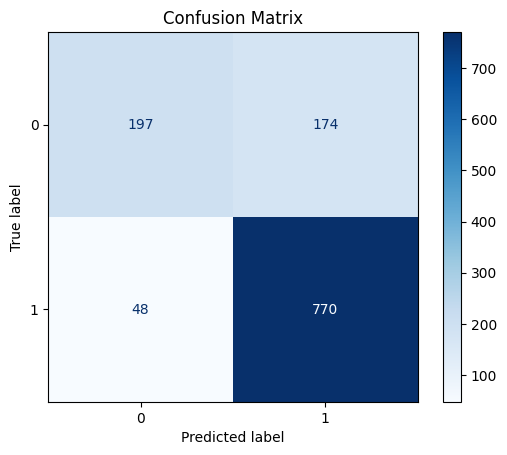

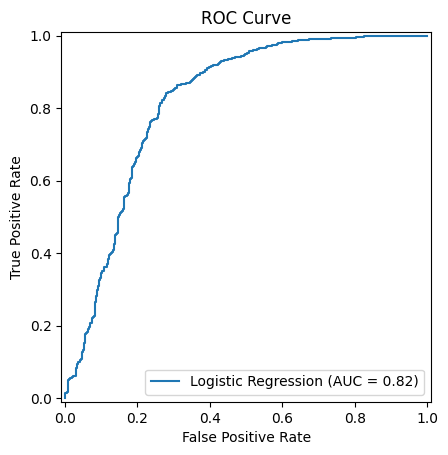

In [28]:
# Generate the confusion matrix array
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")

# Calculate Peirce Skill Score (PSS)
# Also known as True Positive Rate - False Positive Rate
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn) # This is the same as Recall
fpr = fp / (fp + tn)
pss = tpr - fpr
print(f"Peirce Skill Score (PSS): {pss:.2f}")

# Calculate Heidke Skill Score (HSS)
numerator = 2 * (tp * tn - fp * fn)
denominator = (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)
hss = numerator / denominator

print(f"Heidke Skill Score (HSS): {hss:.2f}")

# Generate a report with precision, recall, and f1-score for each class
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Failure (0)', 'Success (1)']))


# Get the probabilities of predicting a success
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]

# Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate the AUC
roc_auc = auc(fpr, tpr)

# Plot the curve
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name='Logistic Regression')
display.plot()
plt.title('ROC Curve')
plt.show()